In [38]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from quantificationlib.baselines.cc import CC, PCC
from quantificationlib.baselines.ac import AC, PAC
from quantificationlib.multiclass.df import HDy
from quantificationlib.multiclass.em import EM

import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(".."))

from src.legacy_cbms26.bags import generate_bags

from aeon.classification.deep_learning import FCNClassifier, LITETimeClassifier

from src.legacy_cbms26.preprocess import ECGPreprocessor

In [39]:
class PatientECGAnalyzer:
    def __init__(self, preprocessor: ECGPreprocessor):
        self.preprocessor = preprocessor
        self.record_name = None
        self.raw_signal = None
        self.annotations = None
        
        self.segments = []
        self.labels = []

    def load(self, record_name: str):
        self.record_name = record_name

        record, annotation = self.preprocessor.load_record(record_name)

        self.raw_signal = record.p_signal[:, 0]
        self.annotations = annotation

        X, y, _ = self.preprocessor.segment_record(record, annotation, record_name)

        self.segments = X
        self.labels = y

        print(f'Patient {record_name} compiled.')
        print(f'Original record shape: {self.raw_signal.shape}')
        print(f'Total segments extracted: {len(self.segments)}')

    def get_sequential_segments(self):
        return self.segments
    
    def get_labels(self, binary: bool = True):
        if binary:
            return np.array([1 if s == 'N' else 0 for s in self.labels])
        return self.labels
    
    def get_summary(self):
        return {
            'record': self.record_name,
            'window_size': self.preprocessor.window_size,
            'normalization': self.preprocessor.normalization,
            'sampling_rate': self.annotations.fs if hasattr(self.annotations, 'fs') else 'N/A'
        }

In [40]:
data_dir = "./data/raw/mitdb"
preprocessor = ECGPreprocessor(data_dir=data_dir, window_size=360)

analyzer = PatientECGAnalyzer(preprocessor)

analyzer.load('100')


# segmentos = analyzer.get_sequential_segments()
# for i, seg in enumerate(segmentos):
#     pass

print(f"Análise concluída para o registro {analyzer.get_summary()['record']}")

Patient 100 compiled.
Original record shape: (650000,)
Total segments extracted: 2274
Análise concluída para o registro 100


In [41]:
class ECGQuantificationAnalyzer:
    def __init__(self, patient_analyzer: PatientECGAnalyzer):
        self.patient = patient_analyzer
        # self.model = model  # Seu classificador pré-treinado
        self.predictions = None
        self.prevalence = None

        self.segments = None

    def quantify(self, quantifier):
        """
        Gera as predições para cada segmento e aplica o quantificador
        para estimar a prevalência de batimentos normais (N).
        """
        self.segments = self.patient.get_sequential_segments()

        self.predictions = quantifier.estimator_test.predict(self.segments)
        
        self.prevalence = quantifier.predict(self.segments)[1]
        return self.prevalence

    def plot_analysis(self):
        """
        Gera o gráfico combinado: sinal original vs. prevalência/predições.
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
        
        # Plot Superior: Sinal ECG Original
        time_axis = np.arange(len(self.patient.raw_signal))
        ax1.plot(time_axis, self.patient.raw_signal, color='#2c3e50', lw=0.5)
        ax1.set_title(f"Sinal Original - Registro: {self.patient.record_name}")
        ax1.set_ylabel("Amplitude (mV)")
        
        # Plot Inferior: Radius/Prevalence Plot
        # Vamos mapear as predições ao longo do tempo para ver a densidade
        num_segments = len(self.segments)
        x_segments = np.linspace(0, len(self.patient.raw_signal), num_segments)
        
        # Plot de dispersão para mostrar onde ocorrem as anomalias (0) e normais (1)
        colors = ['red' if p == 0 else 'green' for p in self.predictions]
        ax2.scatter(x_segments, self.predictions, c=colors, s=10, alpha=0.5)
        
        # Linha de Prevalência Estimada
        ax2.axhline(y=self.prevalence, color='blue', linestyle='--', 
                    label=f'Prevalência Estimada: {self.prevalence:.2%}')
        
        ax2.set_title("Predições por Segmento e Prevalência Global")
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(['Anormal (0)', 'Normal (1)'])
        ax2.legend(loc='right')
        
        plt.tight_layout()
        plt.show()

In [42]:
data = np.load("./data/processed/mitdb_preprocessed.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
rec_train = data["rec_train"]
rec_test = data["rec_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positives:", np.sum(y_train==1))
print("Test positives:", np.sum(y_test==1))

Train shape: (77518, 360)
Test shape: (35129, 360)
Train positives: 46054
Test positives: 28998


In [43]:
# estimator_cc = RandomForestClassifier(n_estimators=150, random_state=42)
# cc = CC(estimator_test=estimator_cc)
cc = joblib.load('../models/cc_random_forest.pkl')

In [44]:
# estimator_emq = SVC(kernel="rbf", probability=True)
em = joblib.load('../models/emq_svm.pkl')
# em.fit(X_train, y_train)

In [45]:
estimator_acc = SVC(kernel="rbf", probability=True)
acc = AC(estimator_train=estimator_acc, estimator_test=estimator_acc)
acc.fit(X_train, y_train)

# acc = joblib.load('../models/acc_svm.pkl')

,estimator_train,SVC(probability=True)
,estimator_test,SVC(probability=True)
,distance,'HD'
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True


In [50]:
acc = joblib.load('../models/acc_svm.pkl')

In [47]:
estimator_lite = LITETimeClassifier().load_model(['./best_model0.keras', './best_model1.keras', './best_model2.keras', './best_model3.keras', './best_model4.keras'], classes=[0, 1])
cc_lite = CC(estimator_test=estimator_lite)
cc_lite.classes_ = np.array([0, 1])

In [48]:
# print(np.unique(rec_test))

patient_data = PatientECGAnalyzer(preprocessor)
patient_data.load('221')
# np.unique(patient_data.get_labels(), return_counts=True)
# cc.predict(patient_data.segments)

Patient 221 compiled.
Original record shape: (650000,)
Total segments extracted: 2462


In [57]:
mae_per_minute = {
    'CC-RF': [],
    'CC-LITE': [],
    'ACC-SVM': [],
    'EMQ-SVM': []
}
mae = 0

for i in range(0, 2462, 30):
    start, end = i, i + 30
    
    if end > 2462:
        end = 2462

    bag_x = patient_data.segments[start:end]
    bag_y = patient_data.get_labels()[start:end]

    _, counts = np.unique(bag_y, return_counts=True)
    true_prevalence = counts[-1] / counts.sum()
    
    cc_rf_prevalence = cc.predict(bag_x)[1]
    emq_prevalence = em.predict(bag_x)[1]
    cc_lite_prevalence = cc_lite.predict(bag_x)[1]
    acc_prevalence = acc.predict(bag_x)[1]

    cc_rf_mae = abs(cc_rf_prevalence - true_prevalence) + (mae_per_minute['CC-RF'][-1] if len(mae_per_minute['CC-RF']) > 0 else 0)
    cc_lite_mae = abs(cc_lite_prevalence - true_prevalence) + (mae_per_minute['CC-LITE'][-1] if len(mae_per_minute['CC-LITE']) > 0 else 0)
    emq_mae = abs(emq_prevalence - true_prevalence) + (mae_per_minute['EMQ-SVM'][-1] if len(mae_per_minute['EMQ-SVM']) > 0 else 0)
    acc_mae = abs(acc_prevalence - true_prevalence) + (mae_per_minute['ACC-SVM'][-1] if len(mae_per_minute['ACC-SVM']) > 0 else 0)

    mae_per_minute['CC-RF'].append(cc_rf_mae)
    mae_per_minute['EMQ-SVM'].append(emq_mae)
    mae_per_minute['ACC-SVM'].append(acc_mae)
    mae_per_minute['CC-LITE'].append(cc_lite_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

In [59]:
len(mae_per_minute['ACC-SVM'])

83

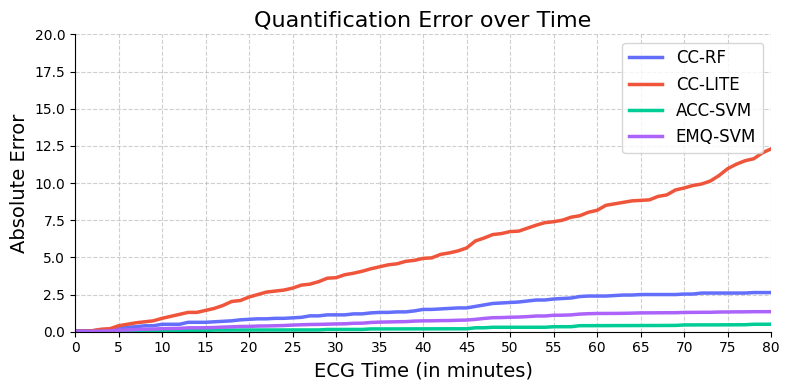

In [88]:
# fig = make_subplots(
#   rows=2, cols=1, 
#   shared_xaxes=True,
#   vertical_spacing=0.1,
#   subplot_titles=(f"Sinal ECG Original (Registro {patient_data.record_name})", "Evolução do Erro de Prevalência (MAE Acumulado)"),
#   row_heights=[0.3, 0.7]
# )

# step = max(1, len(patient_data.raw_signal) // 5000) 

# fig.add_trace(
#   go.Scatter(y=patient_data.raw_signal[::step], mode='lines', line=dict(color='black', width=1), name="ECG"),
#   row=1, col=1
# )

plt.figure(figsize=(8, 4))
minutes = list(range(0, len(mae_per_minute['ACC-SVM'])))

colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

for i, (label, values) in enumerate(mae_per_minute.items()):
    # print(values)
    plt.plot(
        minutes, values, 
        label=label, 
        color=colors[i % len(colors)],
        linewidth=2.5,
        # marker='o',      # Marcador circular
        markersize=5,
        markerfacecolor='white', # Destaca o centro do marcador
        markeredgewidth=1.5
    )

plt.title('Quantification Error over Time', fontsize=16)
plt.xlabel('ECG Time (in minutes)', fontsize=14)
plt.ylabel('Absolute Error', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6, which='both')
plt.xlim(0, 80)
plt.ylim(0, 20)
plt.xticks(range(0, 81, 5)) # Garante que cada minuto apareça no eixo X

plt.legend(loc='upper right', frameon=True, fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('acumulated_error.pdf')

In [42]:
preds = cc.estimator_test.predict(patient_data.segments)
true_labels = patient_data.get_labels()

true_labels

array([0, 1, 1, ..., 1, 1, 1], shape=(1824,))

ValueError: x and y must have same first dimension, but have shapes (30,) and (83,)

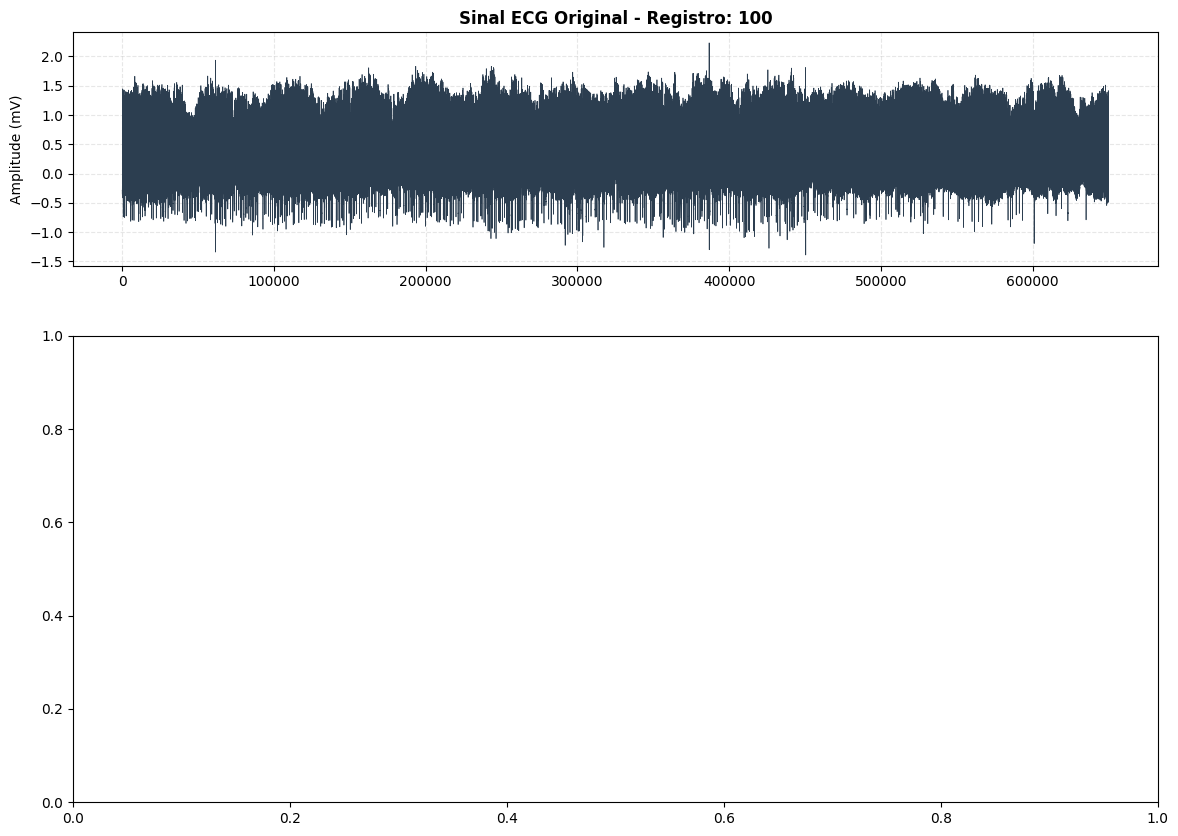

In [89]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ecg_quantification_report(raw_signal, mae_per_minute, record_name):
    """
    Gera um relatório visual comparativo:
    Topo: Sinal de ECG original.
    Base: Evolução do erro acumulado dos quantificadores.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]})
    
    # --- PARTE SUPERIOR: Sinal de ECG ---
    # Plotamos uma amostra ou o sinal inteiro (com downsampling para performance)
    ax1.plot(raw_signal, color='#2c3e50', lw=0.5)
    ax1.set_title(f"Sinal ECG Original - Registro: {record_name}", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Amplitude (mV)")
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # --- PARTE INFERIOR: Relatório de Prevalência (MAE) ---
    minutes = list(range(1, 31))
    colors = ['#4A90E2', '#D0021B', '#7ED321', '#9013FE']
    
    for i, (label, values) in enumerate(mae_per_minute.items()):
        ax2.plot(minutes, values, 
                 label=label, 
                 color=colors[i % len(colors)],
                 linewidth=2.5,
                 marker='o', 
                 markersize=4,
                 markeredgewidth=1)

    ax2.set_title("Relatório de Prevalência Estimada (Erro Absoluto Acumulado)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Tempo de Monitoramento (Minutos)")
    ax2.set_ylabel("MAE Acumulado")
    ax2.set_xlim(1, 30)
    ax2.set_xticks(range(1, 31))
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(loc='upper right', title="Métodos")

    # Estilização final
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
plot_ecg_quantification_report(patient_data.raw_signal, mae_per_minute, "100")